## 5. Stationarity Tests

ADF and KPSS are diagnostics, not an automatic modelling oracle. The conservative rule used here is ADF p-value `< 0.05` together with KPSS p-value `> 0.05`, but economic interpretation still matters. Index/price-level variables can often be represented by log differences, while rate variables such as the cash rate and unemployment rate are usually more meaningful as percentage-point changes. Any `I(2)` result is flagged for caution rather than treated as unquestioned evidence that second differencing must be used.

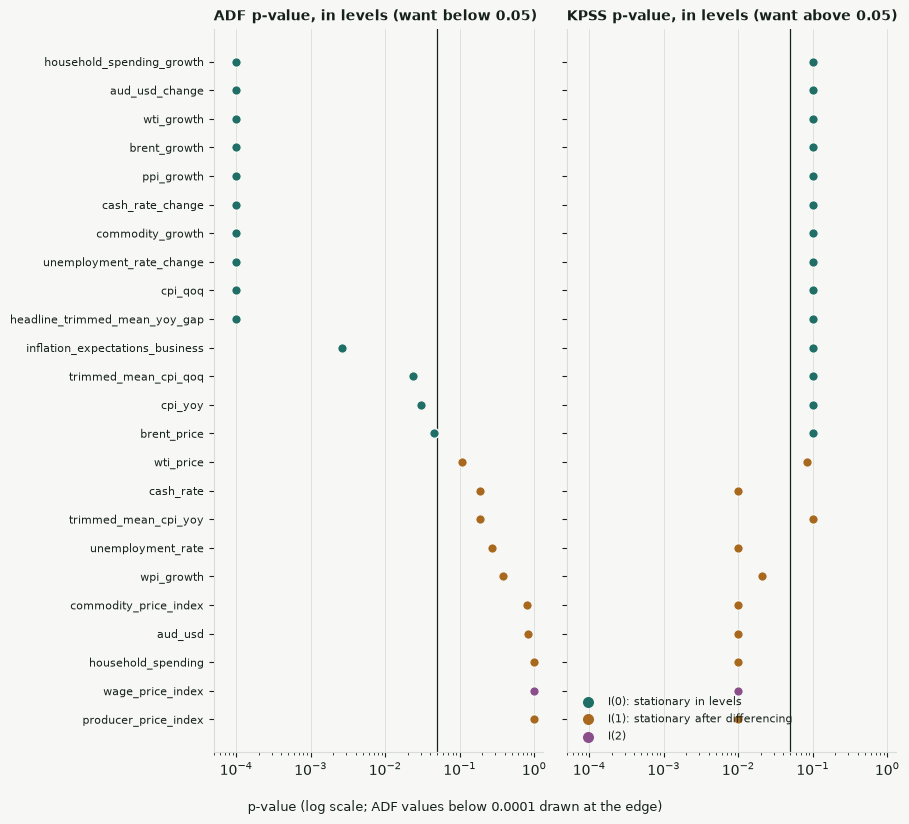

In [7]:
eda_df = df.set_index('quarter_period')
STATIONARITY_COLS = [column for column in CPI_FAMILY_BASE_COLS + CPI_DERIVED_DIAGNOSTIC_COLS if column in df_model.columns] + EXTERNAL_BASE_COLS

def clean_series(column: str) -> pd.Series:
    return pd.to_numeric(eda_df[column], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()


def safe_adf(series: pd.Series) -> float:
    series = series.dropna()
    if len(series) < 12 or series.nunique() < 3:
        return np.nan
    try:
        return float(adfuller(series, autolag='AIC')[1])
    except Exception:
        return np.nan


def safe_kpss(series: pd.Series) -> float:
    series = series.dropna()
    if len(series) < 12 or series.nunique() < 3:
        return np.nan
    try:
        return float(kpss(series, regression='c', nlags='auto')[1])
    except Exception:
        return np.nan


def is_growth_or_change_column(column: str) -> bool:
    return column in set(CPI_FAMILY_BASE_COLS + CPI_DERIVED_DIAGNOSTIC_COLS) or column.endswith('_growth') or column.endswith('_change')


RATE_LEVEL_COLUMNS = {'cash_rate', 'unemployment_rate', 'inflation_expectations_business'}

def should_use_log_diff(column: str, series: pd.Series) -> bool:
    return column not in RATE_LEVEL_COLUMNS and not is_growth_or_change_column(column) and len(series) > 0 and float((series > 0).mean()) >= 0.80


def stationarity_variants(column: str, series: pd.Series) -> dict[str, pd.Series]:
    variants = {
        'level': series,
        'diff1': series.diff(),
        'diff2': series.diff().diff(),
    }
    variants['log_diff1'] = np.log(series.where(series > 0)).diff() if should_use_log_diff(column, series) else pd.Series(dtype='float64')
    return variants


def integration_order_from_tests(row: pd.Series) -> str:
    def stationary(prefix: str) -> bool:
        adf_ok = pd.notna(row[f'{prefix}_adf_p']) and row[f'{prefix}_adf_p'] < 0.05
        kpss_ok = pd.notna(row[f'{prefix}_kpss_p']) and row[f'{prefix}_kpss_p'] > 0.05
        return bool(adf_ok and kpss_ok)
    if stationary('level'):
        return 'I(0)'
    if stationary('diff1') or stationary('log_diff1'):
        return 'I(1)'
    if stationary('diff2'):
        return 'I(2)'
    return 'unclear'


stationarity_rows = []
for column in STATIONARITY_COLS:
    series = clean_series(column)
    row = {'variable': column, 'n_obs': int(len(series))}
    for variant_name, variant_series in stationarity_variants(column, series).items():
        row[f'{variant_name}_adf_p'] = safe_adf(variant_series)
        row[f'{variant_name}_kpss_p'] = safe_kpss(variant_series)
    stationarity_rows.append(row)

stationarity = pd.DataFrame(stationarity_rows)
stationarity['integration_order'] = stationarity.apply(integration_order_from_tests, axis=1)
stationarity['interpretation_note'] = np.select(
    [
        stationarity['variable'].isin(RATE_LEVEL_COLUMNS),
        stationarity['integration_order'].eq('I(2)'),
        stationarity['variable'].str.endswith('_change'),
    ],
    [
        'rate level: prefer percentage-point changes for Elastic Net screening',
        'I(2) diagnostic: verify cautiously before using second differences',
        'rate/growth change feature: already an economically interpretable transform',
    ],
    default='',
)
with plt.rc_context(BOOK_STYLE):
    st = stationarity.dropna(subset=["level_adf_p"]).sort_values("level_adf_p", ascending=False).reset_index(drop=True)
    colour = {"I(0)": ACCENT, "I(1)": HIGHLIGHT, "I(2)": "#8a4f8a", "unclear": MUTED}
    floor = 1e-4
    fig, (a, b) = plt.subplots(1, 2, figsize=(9.2, 0.27 * len(st) + 1.8), sharey=True)
    for ax, col, title in ((a, "level_adf_p", "ADF p-value, in levels (want below 0.05)"),
                           (b, "level_kpss_p", "KPSS p-value, in levels (want above 0.05)")):
        ax.axvline(0.05, color=INK, linewidth=0.9)
        for y, r in st.iterrows():
            ax.scatter(max(r[col], floor), y, s=48, color=colour.get(r["integration_order"], MUTED), edgecolor=PAPER,
                       linewidth=1.0, zorder=3)
        ax.set_xscale("log")
        ax.set_xlim(floor / 2, 1.3)
        ax.set_title(title, loc="left", fontsize=10, fontweight="bold")
        ax.grid(axis="y", visible=False)
    a.set_yticks(range(len(st)), st["variable"], fontsize=8.2)
    for key, label in (("I(0)", "I(0): stationary in levels"), ("I(1)", "I(1): stationary after differencing"),
                       ("I(2)", "I(2)"), ("unclear", "unclear")):
        if (st["integration_order"] == key).any():
            b.scatter([], [], s=48, color=colour[key], label=label)
    b.legend(frameon=False, fontsize=8, loc="lower left")
    fig.supxlabel("p-value (log scale; ADF values below 0.0001 drawn at the edge)", fontsize=9)
    fig.tight_layout()
    plt.show()

**Interpretation.** The two CPI targets behave differently: headline `cpi_yoy` is
borderline stationary at level (ADF p=0.0299, just under the 0.05 cutoff), but
`trimmed_mean_cpi_yoy` is not (level ADF p=0.1896 fails to reject a unit root) — it only
passes both tests after first-differencing (ADF p=0.0000). `unemployment_rate` (ADF
p=0.2713, KPSS p=0.010) and `cash_rate` (ADF p=0.1866, KPSS p=0.010) are also non-stationary
at level by both tests. This mixed picture — one target roughly stationary, one not, plus
two key macro drivers clearly not — is exactly why §4.4 SVAR runs its systems in levels
rather than first differences: differencing would fix `trimmed_mean_cpi_yoy`, unemployment,
and the cash rate, but would over-difference the already-stationary `cpi_yoy`, and running
two systems on different transforms would break the System A/System B comparison.